# Federated Learning Results Visualization

This notebook reads the CSV logs generated by `flower_baseline.py` and regenerates the accuracy and time comparison plots.

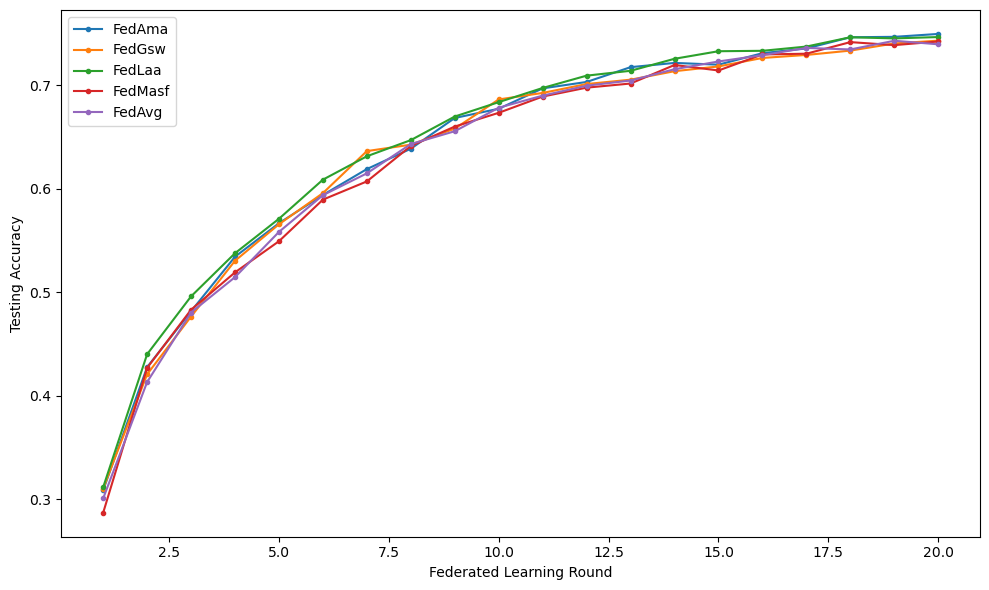

FedAma: mean Duration_Sec = 8.733100
FedGsw: mean Duration_Sec = 8.626202
FedLaa: mean Duration_Sec = 8.693051
FedMasf: mean Duration_Sec = 8.718934
FedAvg: mean Duration_Sec = 8.724572


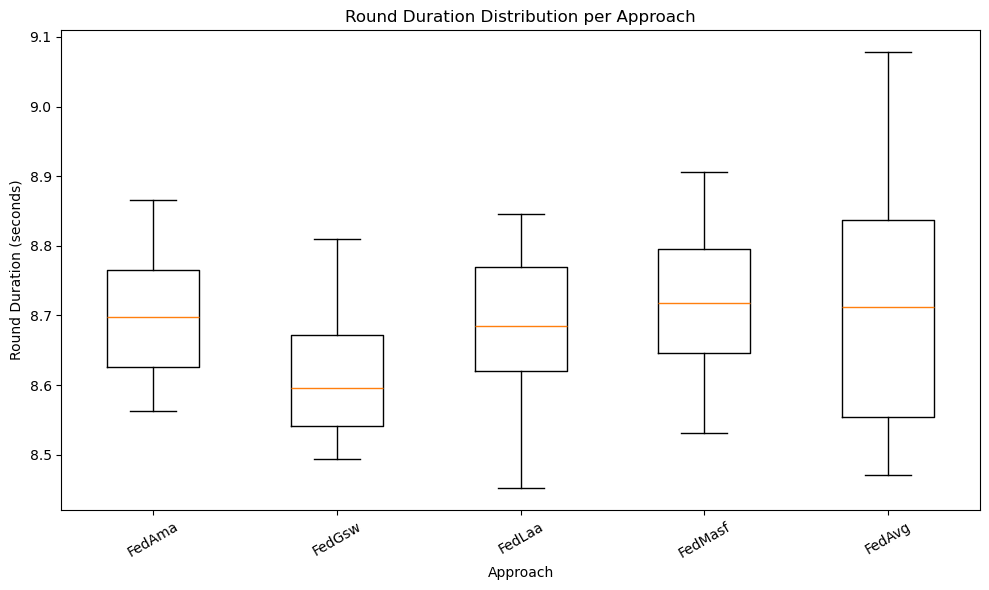

In [4]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

MARKER_SIZE = 3

def strategy_display_name(strategy_raw: str) -> str:
    s = str(strategy_raw).strip()
    if len(s) >= 4 and s[:3].lower() == "fed":
        tail = s[3:]
        if tail:
            return "Fed" + tail[:1].upper() + tail[1:]
        return "Fed"
    if s:
        return s[:1].upper() + s[1:]
    return s

def load_results(csv_dir="csv", pattern="baseline_*.csv"):
    if not os.path.exists(csv_dir):
        return {}

    results = {}
    csv_files = sorted(glob.glob(os.path.join(csv_dir, pattern)))

    for file_path in csv_files:
        filename = os.path.basename(file_path)
        try:
            stem = filename[:-4] if filename.lower().endswith(".csv") else filename
            parts = stem.split("_")

            if len(parts) < 5 or parts[0].lower() != "baseline":
                raise ValueError

            strategy_raw = parts[1]
            model_key = parts[2]
            clients_key = parts[-1]
            dataset_key = "_".join(parts[3:-1])

            df = pd.read_csv(file_path, sep=None, engine="python")
            if "Round" not in df.columns:
                raise ValueError

            display_name = strategy_display_name(strategy_raw)
            group_key = f"{model_key}_{dataset_key}_{clients_key}"
            results.setdefault(group_key, {})[display_name] = df

        except Exception:
            pass

    return results

def merge_groups_for_plot(all_results):
    merged = {}
    for _, strat_map in all_results.items():
        for strat, df in strat_map.items():
            if strat not in merged:
                merged[strat] = df
            else:
                a = merged[strat]
                if len(df) > len(a):
                    merged[strat] = df
    return merged

def plot_accuracy(data_dict, output_dir="results", filename="accuracy_notebook_all.pdf"):
    fig, ax = plt.subplots(figsize=(10, 6))
    for strategy, df in data_dict.items():
        if "Round" not in df.columns or "Accuracy" not in df.columns:
            continue
        ax.plot(df["Round"], df["Accuracy"], label=strategy, marker="o", markersize=MARKER_SIZE)
    ax.set_xlabel("Federated Learning Round")
    ax.set_ylabel("Testing Accuracy")
    ax.legend()
    fig.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, filename))
    plt.show()

def print_mean_round_time(data_dict):
    for strategy, df in data_dict.items():
        if "Duration_Sec" not in df.columns:
            continue
        s = pd.to_numeric(df["Duration_Sec"], errors="coerce").dropna()
        if len(s) == 0:
            continue
        print(f"{strategy}: mean Duration_Sec = {float(s.mean()):.6f}")

def plot_round_time_boxplot(data_dict, output_dir="results", filename="time_notebook_all.pdf"):
    items = []
    labels = []
    for strategy, df in data_dict.items():
        if "Duration_Sec" not in df.columns:
            continue
        s = pd.to_numeric(df["Duration_Sec"], errors="coerce").dropna()
        if len(s) == 0:
            continue
        items.append(s.values)
        labels.append(strategy)

    if not items:
        return

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(items, tick_labels=labels, showfliers=False)
    ax.set_xlabel("Approach")
    ax.set_ylabel("Round Duration (seconds)")
    ax.set_title("Round Duration Distribution per Approach")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    os.makedirs(output_dir, exist_ok=True)
    fig.savefig(os.path.join(output_dir, filename))
    plt.show()

all_results = load_results()
data_dict = merge_groups_for_plot(all_results)

plot_accuracy(data_dict)
print_mean_round_time(data_dict)
plot_round_time_boxplot(data_dict)